Cell 1 — Imports and load data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import os

matplotlib.rcParams['figure.figsize'] = (10, 5)
os.makedirs("../reports/figures", exist_ok=True)

df = pd.read_csv("../data/processed/seoul_congestion_cleaned_v1.csv")
df["collected_at"] = pd.to_datetime(df["collected_at"])

print(df.shape)
print(df.columns.tolist())
print(df.dtypes)

(805, 13)
['collected_at', 'location_name', 'api_reported_time', 'congestion_status_raw', 'congestion_msg', 'congestion_level_3class', 'source_api', 'status_code', 'raw_response', 'date', 'hour', 'day_of_week', 'weekend_flag']
collected_at               datetime64[us]
location_name                         str
api_reported_time                     str
congestion_status_raw                 str
congestion_msg                        str
congestion_level_3class               str
source_api                            str
status_code                         int64
raw_response                          str
date                                  str
hour                                int64
day_of_week                           str
weekend_flag                         bool
dtype: object


Cell 2 — Data overview

In [9]:
print("Date range:", df["collected_at"].min(), "→", df["collected_at"].max())
print("Locations:", df["location_name"].nunique())
print("\nClass counts:")
print(df["congestion_level_3class"].value_counts(dropna=False))

Date range: 2026-03-21 00:28:33 → 2026-04-09 15:09:11
Locations: 5

Class counts:
congestion_level_3class
Low       649
High       81
Medium     75
Name: count, dtype: int64


Cell 3 — Missing values

In [10]:
df.isna().sum().sort_values(ascending=False)

collected_at               0
location_name              0
api_reported_time          0
congestion_status_raw      0
congestion_msg             0
congestion_level_3class    0
source_api                 0
status_code                0
raw_response               0
date                       0
hour                       0
day_of_week                0
weekend_flag               0
dtype: int64

Cell 4 — Chart 1: Class distribution

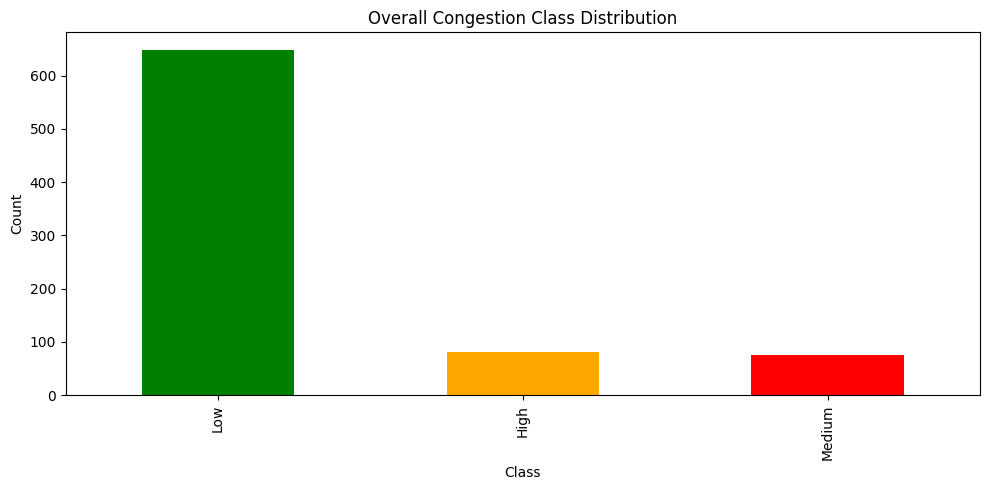

In [11]:
fig, ax = plt.subplots()
df["congestion_level_3class"].value_counts().plot(kind="bar", ax=ax, color=["green","orange","red"])
ax.set_title("Overall Congestion Class Distribution")
ax.set_xlabel("Class")
ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig("../reports/figures/fig1_class_distribution.png", dpi=150)
plt.show()

Cell 5 — Chart 2: Class by location

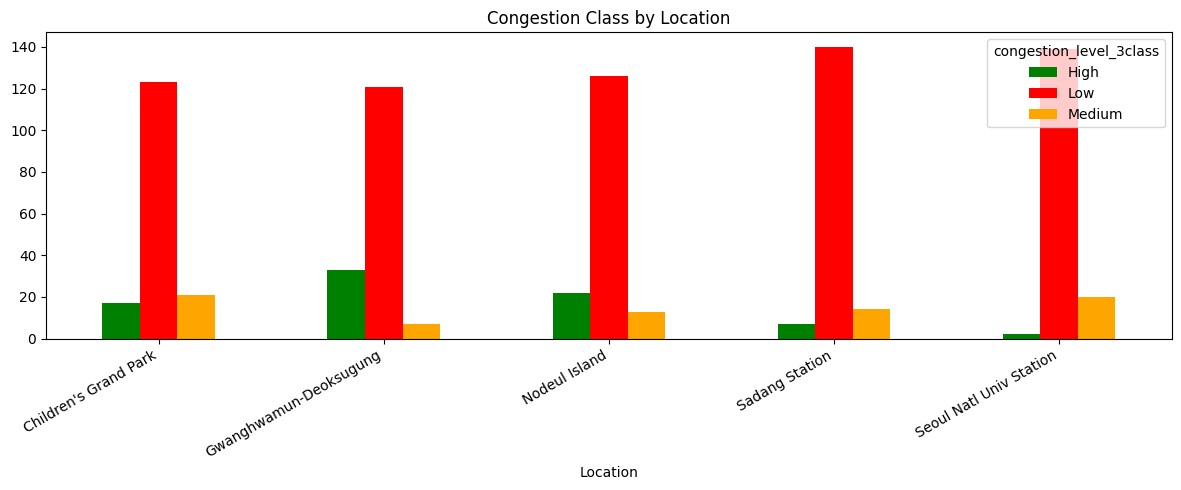

In [12]:
fig, ax = plt.subplots(figsize=(12, 5))
pd.crosstab(df["location_name"], df["congestion_level_3class"]).plot(
    kind="bar", ax=ax, color=["green","red","orange"]
)
ax.set_title("Congestion Class by Location")
ax.set_xlabel("Location")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("../reports/figures/fig2_by_location.png", dpi=150)
plt.show()

Cell 6 — Chart 3: Congestion by hour

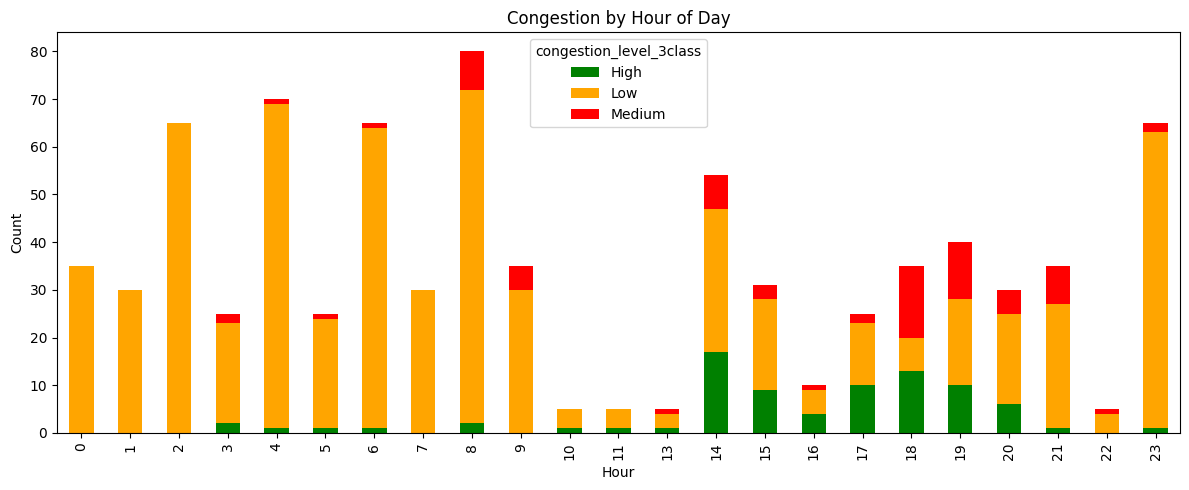

In [13]:
fig, ax = plt.subplots(figsize=(12, 5))
hourly = pd.crosstab(df["hour"], df["congestion_level_3class"])
hourly.plot(kind="bar", stacked=True, ax=ax, color=["green","orange","red"])
ax.set_title("Congestion by Hour of Day")
ax.set_xlabel("Hour")
ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig("../reports/figures/fig3_by_hour.png", dpi=150)
plt.show()

Cell 7 — Chart 4: Weekday vs weekend

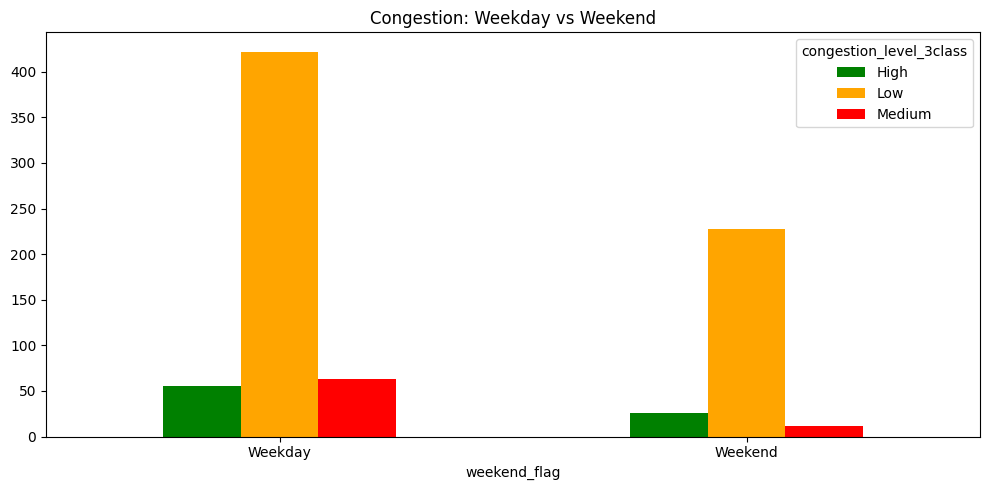

In [14]:
fig, ax = plt.subplots()
pd.crosstab(df["weekend_flag"], df["congestion_level_3class"]).plot(
    kind="bar", ax=ax, color=["green","orange","red"]
)
ax.set_xticklabels(["Weekday", "Weekend"], rotation=0)
ax.set_title("Congestion: Weekday vs Weekend")
plt.tight_layout()
plt.savefig("../reports/figures/fig4_weekend_vs_weekday.png", dpi=150)
plt.show()

Cell 8 — Chart 5: Timeline for one location

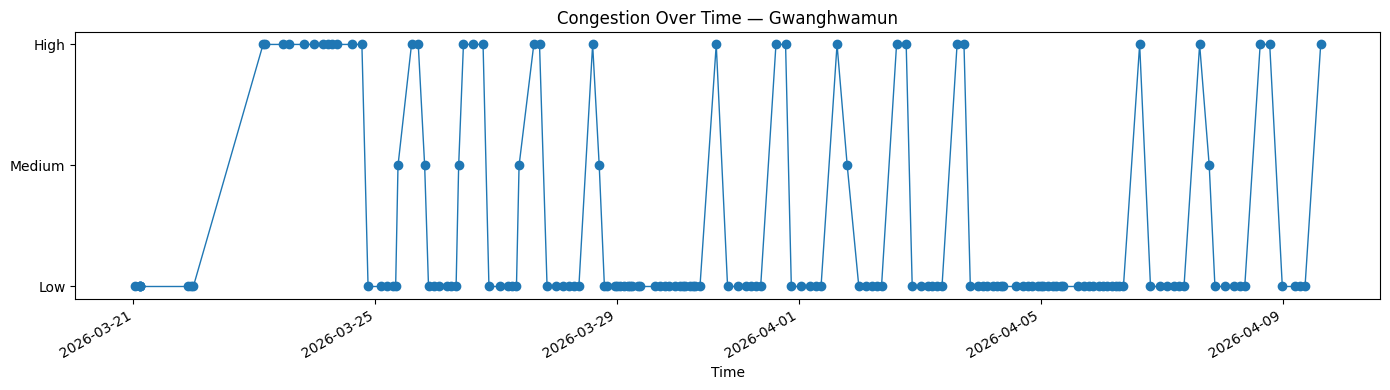

In [15]:
one = df[df["location_name"] == "Gwanghwamun-Deoksugung"].copy()
one = one.sort_values("collected_at")

# Map labels to numbers for plotting
level_map = {"Low": 0, "Medium": 1, "High": 2}
one["level_num"] = one["congestion_level_3class"].map(level_map)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(one["collected_at"], one["level_num"], marker="o", linewidth=1)
ax.set_yticks([0, 1, 2])
ax.set_yticklabels(["Low", "Medium", "High"])
ax.set_title("Congestion Over Time — Gwanghwamun")
ax.set_xlabel("Time")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("../reports/figures/fig5_timeline_gwanghwamun.png", dpi=150)
plt.show()

Cell 9 — Write your findings

In [ ]:
findings = """
## Week 5 EDA Findings

1. [Low is dominant]
2. [Gwanghwamun-deoksugung has most High congestion]
3. [18:00 and 14:00 seem busiest based on chart 3]
4. [weekday vs weekend shows a difference, weekend is more calm]
5. [Write whether data coverage looks sufficient]
6. [Note any class imbalance concern you spotted]
7. [Note anything unusual in the timeline chart]
"""
print(findings)


## Week 5 EDA Findings

1. [Write what class is most common — e.g. Medium is dominant]
2. [Write which location has most High congestion]
3. [Write which hours seem busiest based on chart 3]
4. [Write whether weekday vs weekend shows a difference]
5. [Write whether data coverage looks sufficient]
6. [Note any class imbalance concern you spotted]
7. [Note anything unusual in the timeline chart]



## Confirm data is model-ready

In [17]:
checks = {
    "Has valid timestamp": df["collected_at"].notna().all(),
    "Has location": df["location_name"].notna().all(),
    "Has congestion class": df["congestion_level_3class"].notna().sum() > len(df) * 0.8,
    "Has hour feature": "hour" in df.columns,
    "Has day_of_week": "day_of_week" in df.columns,
    "Enough rows (>100)": len(df) > 100,
    "All 5 locations present": df["location_name"].nunique() == 5,
}

for check, result in checks.items():
    status = "✅" if result else "❌"
    print(f"{status} {check}")

✅ Has valid timestamp
✅ Has location
✅ Has congestion class
✅ Has hour feature
✅ Has day_of_week
✅ Enough rows (>100)
✅ All 5 locations present


## Findings from Exploratory Data Analysis

### Finding 1 — Class distribution is heavily imbalanced toward Low
Low = 649, High = 81, Medium = 75. This means approximately 80% of all observations are classified as Low congestion.  
**Interpretation:** Low congestion accounts for approximately 80% of all observations, indicating significant class imbalance that must be addressed before modeling.

---

### Finding 2 — Gwanghwamun has the most High congestion, Sadang has almost none
From the location-based chart, Gwanghwamun-Deoksugung shows the highest number of High congestion cases, while Sadang Station has almost none.  
**Interpretation:** Congestion patterns differ significantly by location. Gwanghwamun-Deoksugung shows the highest proportion of High congestion while Sadang Station remains predominantly Low throughout the collection period.

---

### Finding 3 — Rush hours are clearly visible at 8AM and 2–7PM
The hourly distribution shows peaks at 08:00 and between 14:00–19:00. Medium and High congestion levels appear almost exclusively during these periods. Hours 10:00–13:00 contain very little data.  
**Interpretation:** High and Medium congestion observations are concentrated during morning rush hour (8AM) and afternoon/evening hours (14:00–19:00), consistent with typical urban traffic patterns.

---

### Finding 4 — Weekdays have proportionally more High congestion than weekends
Weekdays show a higher total number of Medium and High congestion cases compared to weekends. While totals differ, the proportion of High congestion is relatively similar, but Medium drops noticeably on weekends.  
**Interpretation:** Weekday data contains more Medium and High congestion events proportionally than weekend data, suggesting stronger traffic variation on working days.

---

### Finding 5 — Data coverage is sufficient for preliminary modeling
The dataset contains 805 rows collected across 20 days, 5 locations, and multiple time periods including late night, early morning, and peak hours.  
**Interpretation:** Data collection covers a 20-day period from March 21 to April 9 with readings across all hours of the day, providing sufficient coverage for preliminary classification modeling.

---

### Finding 6 — Class imbalance is a real concern
Low congestion dominates the dataset (~80%), meaning a naive model predicting only Low would achieve high accuracy but poor real-world usefulness.  
**Interpretation:** The severe class imbalance (Low: 80%, High: 10%, Medium: 9%) poses a modeling risk. Accuracy alone will not be a reliable metric — F1 score and confusion matrix analysis will be essential in Weeks 7–9.

---

### Finding 7 — Timeline shows sharp switches between Low and High
The time series visualization for Gwanghwamun-Deoksugung shows rapid transitions between Low and High congestion, with very few Medium states.  
**Interpretation:** The timeline for Gwanghwamun-Deoksugung shows abrupt transitions between Low and High congestion with infrequent Medium states, suggesting the location experiences rapid crowd surges rather than gradual buildup.

---

## Data Limitation

### Midday data collection gap
There is a noticeable lack of data between 10:00 and 13:00 due to scheduling gaps in automated data collection.  
**Note:** Data collection gaps exist around midday (10:00–13:00) due to GitHub Actions scheduling delays, which may underrepresent midday congestion patterns.